<a href="https://colab.research.google.com/github/sofiiamyshelova-prog/python_for_ds_tasks/blob/main/Copy_of_HW_2_1_%D0%9F%D0%BE%D0%B1%D1%83%D0%B4%D0%BE%D0%B2%D0%B0_%D0%BB%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97_%D0%B7%D0%B0_%D0%BE%D0%B4%D0%BD%D0%BE%D1%8E_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D1%8E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдені параметри моделі близькими до ваших найкращих припущень?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
medical_df = pd.read_csv('/content/drive/MyDrive/ML/data/medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


charges = -2091.4206 + 267.2489 * age
RMSE = 4662.505766636395


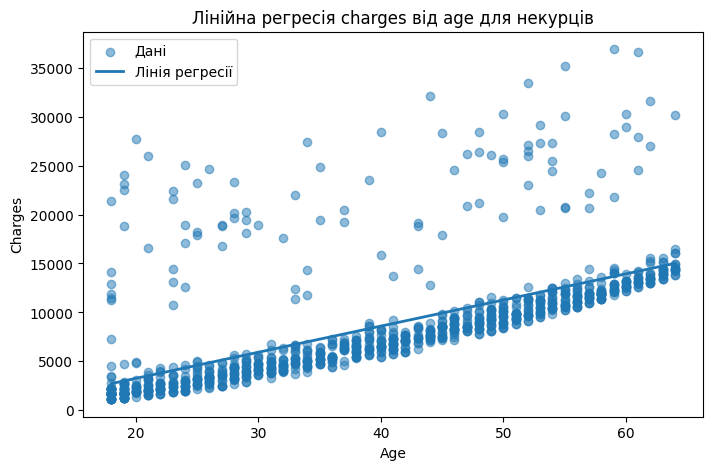

In [15]:
#МНК
x = non_smoker_df['age'].values
y = non_smoker_df['charges'].values

X = np.column_stack((np.ones(len(x)), x)) #додаємо стовпець одиничок

MNK_coef = np.linalg.inv(X.T @ X) @ X.T @ y #розв'язуємо матричне рівняння

b0, b1 = MNK_coef
print(f'charges = {b0:.4f} + {b1:.4f} * age')

#прогноз
predictions_MNK = b0 + b1 * x

#rmse
rmse = np.sqrt(np.mean((y - y_pred) ** 2))
print("RMSE =", rmse)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5, label='Дані')
plt.plot(np.sort(x),
         b0 + b1 * np.sort(x),
         linewidth=2,
         label='Лінія регресії')

plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Лінійна регресія charges від age для некурців')
plt.legend()
plt.show()

lr=0.0001
m = 221.1045843794301
b = -41.98126853149978
RMSE = 4713.250582815521


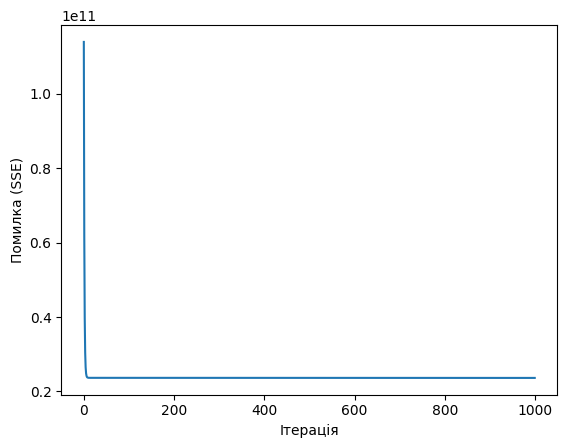

lr=0.00001
m = 220.15455551129122
b = 0.21300652799863293
RMSE = 4715.349750127827


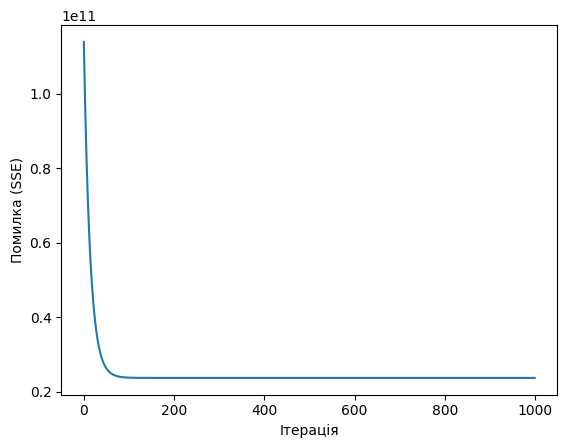

lr=0.000001
m = 213.4575690658104
b = 4.33124916239435
RMSE = 4723.647721473958


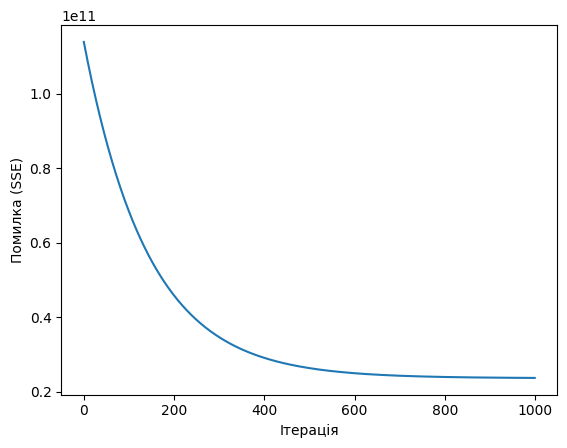

In [12]:
# Градієнтний спуск
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 1] + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, x)
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

#lr=0.0001
m, b, errors = full_batch_gradient_descent(X, y, lr=0.0001, epochs=1000)
predictions_fbgd = m * X[:, 1] + b
print("lr=0.0001")
print("m =", m)
print("b =", b)
rmse_fbgd = np.sqrt(np.mean((y - predictions_fbgd) ** 2))
print("RMSE =", rmse_fbgd)

plt.plot(range(len(errors)), errors)
plt.xlabel("Ітерація")
plt.ylabel("Помилка (SSE)")
plt.show()


#lr=0.00001
m, b, errors = full_batch_gradient_descent(X, y, lr=0.00001, epochs=1000)
predictions_fbgd_1 = m * X[:, 1] + b
print("lr=0.00001")
print("m =", m)
print("b =", b)
rmse_fbgd = np.sqrt(np.mean((y - predictions_fbgd_1) ** 2))
print("RMSE =", rmse_fbgd)

plt.plot(range(len(errors)), errors)
plt.xlabel("Ітерація")
plt.ylabel("Помилка (SSE)")
plt.show()


#lr=0.000001
m, b, errors = full_batch_gradient_descent(X, y, lr=0.000001, epochs=1000)
predictions_fbgd_2 = m * X[:, 1] + b
print("lr=0.000001")
print("m =", m)
print("b =", b)
rmse_fbgd = np.sqrt(np.mean((y - predictions_fbgd_2) ** 2))
print("RMSE =", rmse_fbgd)

plt.plot(range(len(errors)), errors)
plt.xlabel("Ітерація")
plt.ylabel("Помилка (SSE)")
plt.show()

lr=0.0001 найкращий і найшвидше зменшує помилку

In [29]:
from sklearn.linear_model import LinearRegression

# Модель лінійної регресії засобами Scikit-learn (МНК)
lin_reg = LinearRegression()
lin_reg.fit(X, y)
print("coef", lin_reg.coef_)
print("intercept", lin_reg.intercept_)
predictions_sklearn = lin_reg.predict(X)
rmse_sklearn = np.sqrt(np.mean((y - predictions_sklearn) ** 2))
print("rmse_sklearn", rmse_sklearn)

coef [  0.         267.24891283]
intercept -2091.4205565650827
rmse_sklearn 4662.505766636395


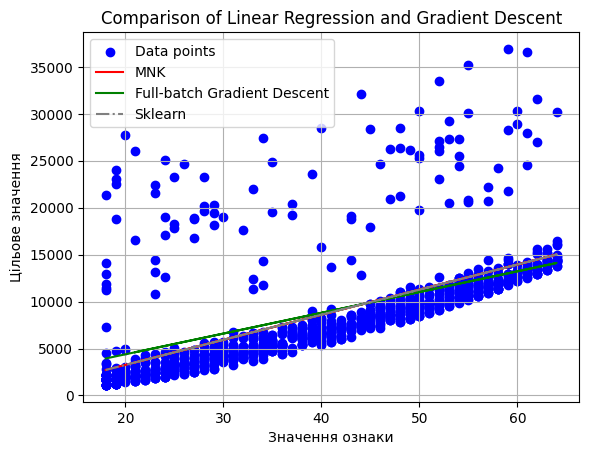

In [28]:
# Візуалізація результатів
plt.scatter(X[:, 1], y, color='blue', label='Data points')
plt.plot(X[:, 1], predictions_MNK, color='red', label='MNK')
plt.plot(X[:, 1], predictions_fbgd, color='green', label='Full-batch Gradient Descent')
plt.plot(X[:, 1], predictions_sklearn, color='gray', linestyle='-.', label='Sklearn') #майже зспівпадає з predictions_MNK
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

Методами МНК та sklearn отримали найменші помилки rmse=4662. В підібраному мною вручну помилка була 4666, що зовсім трошки більше.
Загалом помилка велика, бо є багато даних зосереджених біля прямої і також багато викидів, які сильно впливають на помилку.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

coef [  0.         305.23760211]
intercept 20294.12812691597
rmse_sklearn 10711.00334810241


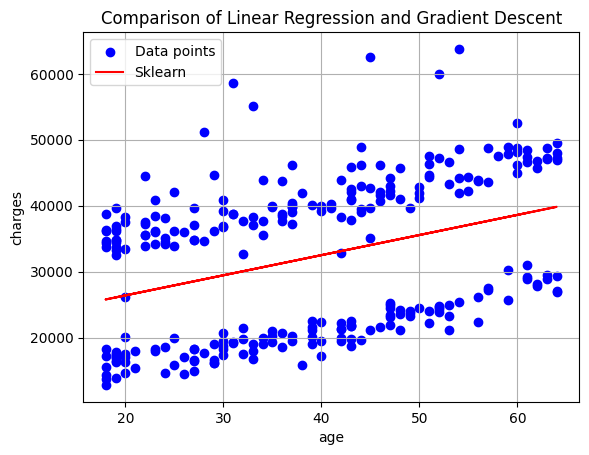

In [34]:
smoker_df = medical_df[medical_df.smoker == 'yes']

x = smoker_df['age'].values
y = smoker_df['charges'].values

X = np.column_stack((np.ones(len(x)), x)) #додаємо стовпець одиничок

# Модель лінійної регресії засобами Scikit-learn (МНК)
lin_reg = LinearRegression()
lin_reg.fit(X, y)
print("coef", lin_reg.coef_)
print("intercept", lin_reg.intercept_)
predictions_sklearn = lin_reg.predict(X)
rmse_sklearn = np.sqrt(np.mean((y - predictions_sklearn) ** 2))
print("rmse_sklearn", rmse_sklearn)

# Візуалізація результатів
plt.scatter(X[:, 1], y, color='blue', label='Data points')
plt.plot(X[:, 1], predictions_sklearn, color='red', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('age')
plt.ylabel('charges')
plt.legend()
plt.grid(True)
plt.show()

на візуалізації видно, що сині точки утворюють дві лінії, а наша регресія знаходиться між ними. було б добре зрозуміти, як розділити дані на ці дві лінії (можливо ще якась ознака) і зробити регресію окремо для кожної.

Станом на зараз модель дуже погано прогнозує charges